Loaded data: 1100 rows, 25 cols

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       1100 non-null   int64  
 1   Study_Hours_Per_Day              1100 non-null   float64
 2   Extracurricular_Hours_Per_Day    1100 non-null   float64
 3   Sleep_Hours_Per_Day              1100 non-null   float64
 4   Social_Hours_Per_Day             1100 non-null   float64
 5   Physical_Activity_Hours_Per_Day  1100 non-null   float64
 6   GPA                              1100 non-null   float64
 7   anxiety_level                    1100 non-null   int64  
 8   self_esteem                      1100 non-null   int64  
 9   mental_health_history            1100 non-null   int64  
 10  depression                       1100 non-null   int64  
 11  headache                       

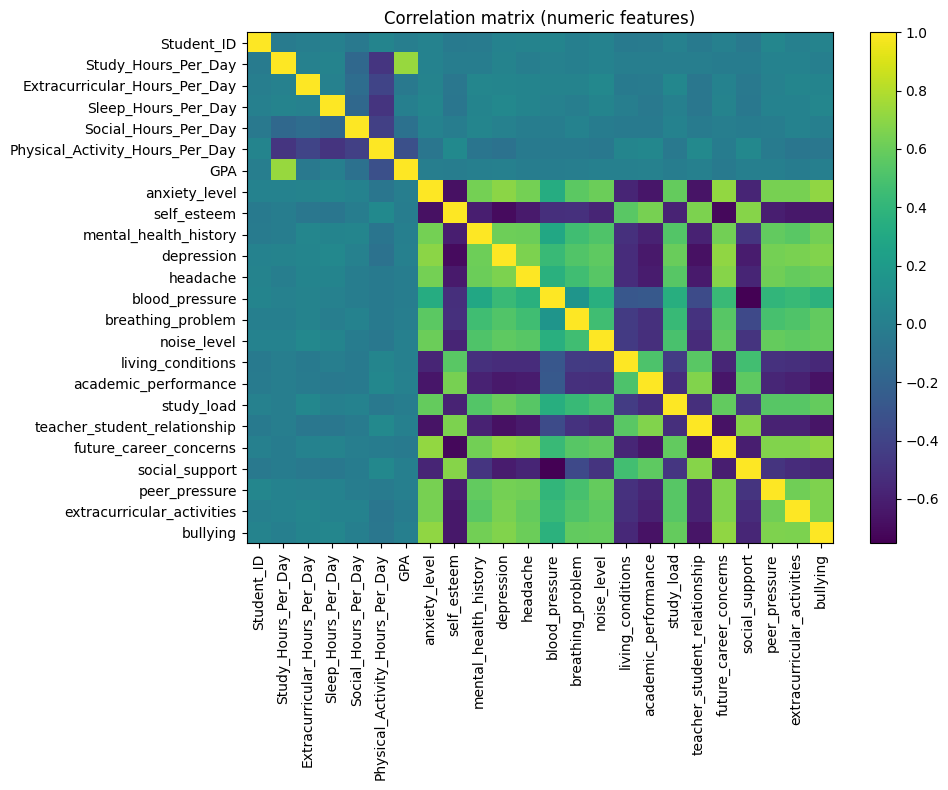

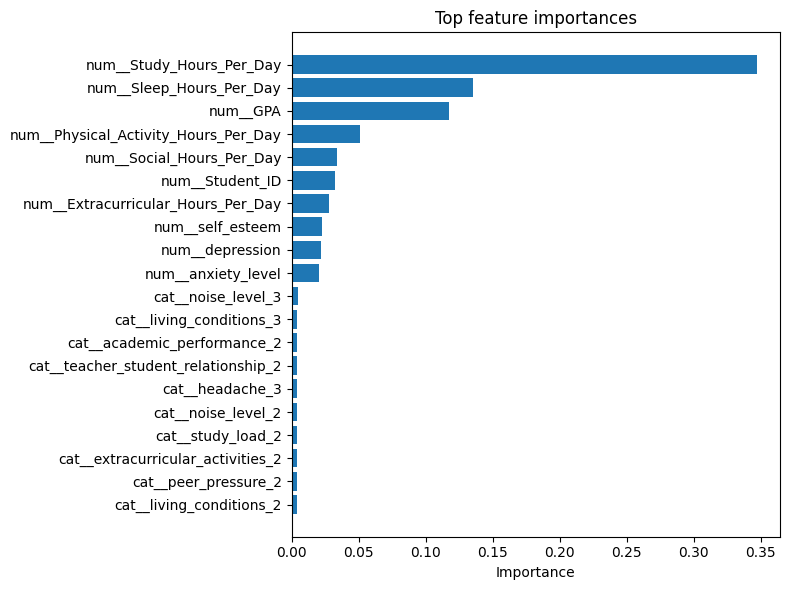

Prediction: 2 Probabilities: [0.33  0.265 0.405]


In [ ]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Try import xgboost; if not present, we'll skip it.
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

import joblib  # for saving models
import seaborn as sns

# --------- USER CONFIG ----------
DATA_PATH = "/content/student_lifestyle_dataset.csv" # change to your CSV path
TARGET_COL = "Stress_Level"         # change if your target column has a different name
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAVE_MODEL_PATH = "best_stress_model.joblib"
# --------------------------------

def load_data(path):
    """Load CSV to pandas DataFrame."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"CSV not found at {path}. Please update DATA_PATH.")
    df = pd.read_csv(path)
    print(f"Loaded data: {df.shape[0]} rows, {df.shape[1]} cols")
    return df

def basic_explore(df):
    """Print basic info and a few rows to inspect."""
    print("\n=== DATA INFO ===")
    print(df.info())
    print("\n=== MISSING VALUES ===")
    print(df.isnull().sum().sort_values(ascending=False).head(20))
    print("\n=== SAMPLE ROWS ===")
    print(df.head(5))
    print("\n=== TARGET DISTRIBUTION ===")
    if TARGET_COL in df.columns:
        print(df[TARGET_COL].value_counts(dropna=False))
    else:
        print(f"Target column '{TARGET_COL}' not found in data.")

def prepare_features(df):
    """
    Split features and target, detect categorical and numerical columns,
    and build preprocessing ColumnTransformer.
    """
    if TARGET_COL not in df.columns:
        raise KeyError(f"Target column '{TARGET_COL}' not found in dataset.")

    # Separate X, y
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL].copy()

    # Encode target variable if it's categorical (needed for some models like XGBoost)
    if y.dtype == 'object' or isinstance(y.iloc[0], str):
        le = LabelEncoder()
        y = le.fit_transform(y)
        print(f"Target variable '{TARGET_COL}' encoded to numerical labels: {le.classes_}")

    # Detect categorical columns (object or low-cardinality numeric)
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    # treat numeric columns with few unique values as categorical (optional)
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    # move low-cardinality numerics to categorical (cardinality threshold)
    CARDINALITY_THRESHOLD = 10
    for c in num_cols[:]:  # iterate copy
        if X[c].nunique(dropna=True) <= CARDINALITY_THRESHOLD:
            cat_cols.append(c)
            num_cols.remove(c)

    print(f"\nDetected {len(num_cols)} numeric cols and {len(cat_cols)} categorical cols.")

    # Preprocessing pipelines
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),   # fill missing numeric with median
        ("scaler", StandardScaler())                     # scale numeric features
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # one-hot encode
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ], remainder="drop")  # drop any other columns

    return X, y, preprocessor, num_cols, cat_cols

def build_and_train_models(X_train, y_train, X_val, y_val, preprocessor):
    """
    Build pipelines for multiple classifiers, train them,
    and return trained models and performance summary.
    """
    models = {}
    results = {}

    # Helper to train pipeline and evaluate
    def train_eval(model_name, estimator, param_grid=None):
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("clf", estimator)
        ])
        if param_grid:
            # run quick grid search (small) to tune
            gs = GridSearchCV(pipe, {"clf__" + k: v for k, v in param_grid.items()},
                              cv=3, n_jobs=-1, verbose=0)
            gs.fit(X_train, y_train)
            best = gs.best_estimator_
            print(f"{model_name} best params: {gs.best_params_}")
            estimator_used = best
        else:
            estimator.fit(X_train, y_train)
            estimator_used = pipe

        # If we passed GridSearchCV, estimator_used is a Pipeline; else wrap pipeline with fitted estimator for consistency
        if not isinstance(estimator_used, Pipeline):
            estimator_used = pipe
            estimator_used.named_steps["clf"] = estimator
        # ensure fitted if not gridsearch
        try:
            # predict on validation
            preds = estimator_used.predict(X_val)
        except Exception:
            # maybe estimator inside pipeline not fitted yet
            estimator_used.fit(X_train, y_train)
            preds = estimator_used.predict(X_val)

        acc = accuracy_score(y_val, preds)
        print(f"{model_name} validation accuracy: {acc:.4f}")
        models[model_name] = estimator_used
        results[model_name] = {"accuracy": acc, "y_pred": preds}
        return estimator_used

    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    rf_params = {"n_estimators": [100, 200], "max_depth": [None, 8]}
    train_eval("RandomForest", rf, param_grid=rf_params)

    # Support Vector Machine (use probability for later)
    svm = SVC(probability=True, random_state=RANDOM_STATE)
    svm_params = {"C": [0.1, 1], "kernel": ["rbf", "linear"]}
    train_eval("SVM", svm, param_grid=svm_params)

    # Logistic Regression (fast baseline)
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr_params = {"C": [0.1, 1, 10]}
    train_eval("LogisticRegression", lr, param_grid=lr_params)

    # XGBoost (optional)
    if HAS_XGB:
        xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=RANDOM_STATE)
        xgb_params = {"n_estimators": [100, 200], "max_depth": [3, 6]}
        train_eval("XGBoost", xgb, param_grid=xgb_params)
    else:
        print("xgboost not installed - skipping XGBoost model (optional).")

    return models, results

def evaluate_best_model(models, results, X_test, y_test):
    """Pick best model by validation accuracy, evaluate on holdout test set, and print metrics."""
    # pick best by accuracy
    best_name = max(results.items(), key=lambda kv: kv[1]["accuracy"])[0]
    best_pipeline = models[best_name]
    print(f"\n=== Selected best model: {best_name} ===")

    # Predict on test set
    y_pred = best_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy ({best_name}): {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Save model
    joblib.dump(best_pipeline, SAVE_MODEL_PATH)
    print(f"Saved best model pipeline to {SAVE_MODEL_PATH}")

    return best_name, best_pipeline

def plot_correlation_heatmap(df, savefig=False):
    """
    Plot correlation heatmap for numeric columns to see relationships.
    """
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.shape[1] < 2:
        print("Not enough numeric columns for correlation heatmap.")
        return
    corr = numeric_df.corr()
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, interpolation="nearest", aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=90)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    if savefig:
        plt.savefig("correlation_heatmap.png",dpi=150)
        print("Saved correlation heatmap to correlation_heatmap.png")
    plt.show()

def plot_feature_importance(best_pipeline, X_sample, feature_names=None, top_n=20):
    """
    Extract feature importances from tree-based model inside pipeline if present
    (RandomForest or XGBoost). If not available, try coefficients (LogisticRegression).
    """
    clf = best_pipeline.named_steps["clf"]

    # Initialize transformed_feature_names before the try block to ensure it's always defined
    transformed_feature_names = None

    # Build feature names after preprocessing (one-hot encoding expands names)
    # We can try to get feature names from the ColumnTransformer + OneHotEncoder
    try:
        preprocessor = best_pipeline.named_steps["preprocessor"]
        # sklearn >= 1.0: get_feature_names_out exists
        transformed_feature_names = preprocessor.get_feature_names_out()
    except Exception:
        # leave None
        transformed_feature_names = feature_names

    importances = None
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
    elif hasattr(clf, "coef_"):
        # logistic regression / linear models
        coefs = clf.coef_
        if coefs.ndim == 1:
            importances = np.abs(coefs)
        else:
            importances = np.mean(np.abs(coefs), axis=0)
    else:
        print("Model does not expose feature importances or coefficients. Skipping importance plot.")
        return

    # if we don't have transformed_feature_names, try to create generic names
    if transformed_feature_names is None:
        transformed_feature_names = [f"f{i}" for i in range(len(importances))]

    # Sort top features
    idx_sorted = np.argsort(importances)[::-1][:top_n]
    top_feats = [transformed_feature_names[i] for i in idx_sorted]
    top_imps = importances[idx_sorted]

    plt.figure(figsize=(8, max(4, 0.3 * len(top_feats))))
    y_pos = np.arange(len(top_feats))
    plt.barh(y_pos, top_imps[::-1])
    plt.yticks(y_pos, top_feats[::-1])
    plt.xlabel("Importance")
    plt.title("Top feature importances")
    plt.tight_layout()
    plt.show()

def demo_predict(best_pipeline):
    """
    Show sample prediction using the saved pipeline. The sample should be aligned with
    the original dataset columns (not preprocessed).
    Adjust the `sample_dict` below to reflect your dataset fields.
    """
    # Example sample — MODIFY THIS to match your dataset columns!
    sample_dict = {
        "Student_ID": 1000,
        "Study_Hours_Per_Day": 5.0,
        "Extracurricular_Hours_Per_Day": 2.0,
        "Sleep_Hours_Per_Day": 7.0,
        "Social_Hours_Per_Day": 1.5,
        "Physical_Activity_Hours_Per_Day": 1.0,
        "GPA": 3.5,
        "anxiety_level": 10,
        "self_esteem": 25,
        "mental_health_history": 0,
        "depression": 0,
        "headache": 0,
        "blood_pressure": 1,
        "breathing_problem": 0,
        "noise_level": 2,
        "living_conditions": 2,
        "academic_performance": 3,
        "study_load": 3,
        "teacher_student_relationship": 4,
        "future_career_concerns": 3,
        "social_support": 4,
        "peer_pressure": 2,
        "extracurricular_activities": 3,
        "bullying": 0
    }

    if not sample_dict:
        print("\nNo sample provided for demo prediction. To run demo prediction, edit 'sample_dict' in demo_predict().")
        return

    sample_df = pd.DataFrame([sample_dict])
    pred = best_pipeline.predict(sample_df)
    if hasattr(best_pipeline.named_steps["clf"], "predict_proba"):
        proba = best_pipeline.predict_proba(sample_df)
        print("Prediction:", pred[0], "Probabilities:", proba[0])
    else:
        print("Prediction:", pred[0])

def check_bias_with_distplot(best_pipeline, X_test, y_test):
    """
    Check prediction bias using probability distribution (distplot / kdeplot).
    Shows:
      - Predicted probability distribution
      - Class-wise distribution (Stress vs No Stress)
      - Prediction label distribution
    """

    # Some models may not have predict_proba (e.g., SVM without probability=True)
    if not hasattr(best_pipeline.named_steps["clf"], "predict_proba"):
        print("\nModel does not support predict_proba \u2192 Cannot compute probability distribution.")
        return

    # Get probabilities
    y_proba = best_pipeline.predict_proba(X_test)
    if y_proba.shape[1] > 1:
        # For multi-class, pick the probability of the predicted class or a specific class if needed
        # For simplicity, let's use the probability of the most likely class (max proba)
        # Or, if target is binary, it's typically the probability of the positive class (index 1)
        if best_pipeline.named_steps["clf"].n_classes_ == 2:
            y_proba_plot = y_proba[:, 1] # Probability of the positive class
        else:
            # For multi-class, let's use the probability of the predicted class
            # This can be more complex to visualize meaningfully, consider pairwise or specific class probas
            # For now, let's just use the max probability, or adapt as needed for specific analysis
            y_proba_plot = np.max(y_proba, axis=1) # Using max probability for multi-class
    else:
        y_proba_plot = y_proba.flatten() # For binary classification where predict_proba returns a single column

    y_pred = best_pipeline.predict(X_test)



def main():
    # Load
    df = load_data(DATA_PATH)

    # Quick exploration
    basic_explore(df)

    # Prepare features and preprocessor
    X, y, preprocessor, num_cols, cat_cols = prepare_features(df)

    # Train/test split (stratify if possible)
    stratify = y if (isinstance(y, np.ndarray) and y.ndim == 1 and len(np.unique(y)) > 1) or \
                     (isinstance(y, pd.Series) and y.nunique() > 1 and y.dtype != "float64") else None
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify)
    # Within temp split, we'll make a validation set for quick tuning
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=(y_temp if stratify is not None else None))

    print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # Train multiple models
    models, results = build_and_train_models(X_train, y_train, X_val, y_val, preprocessor)

    # Evaluate on test set and save best
    best_name, best_pipeline = evaluate_best_model(models, results, X_test, y_test)

    # Plot correlation heatmap (numeric features only)
    plot_correlation_heatmap(df, savefig=True)

    # Plot feature importances (attempt)
    # We need a sample X to obtain transformed feature names; pass X_train head
    try:
        transformed_feature_names_main = None
        # Try to derive names from preprocessor (if scikit supports get_feature_names_out)
        try:
            transformed_feature_names_main = preprocessor.get_feature_names_out()
        except Exception:
            # leave None
            transformed_feature_names_main = None
        plot_feature_importance(best_pipeline, X_train.head(5), feature_names=transformed_feature_names_main, top_n=20)
    except Exception as e:
        print("Could not plot feature importances:\n", e)

    # Demo predict (user must edit sample)
    demo_predict(best_pipeline)

    # Check bias using probability distribution (distplot)
    check_bias_with_distplot(best_pipeline, X_test, y_test)

if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
import joblib # Import joblib for loading the model
from sklearn.preprocessing import LabelEncoder

# Define the path to your saved model (assuming SAVE_MODEL_PATH is defined in the global scope or passed)
# For robustness, we will assume SAVE_MODEL_PATH comes from the main script if this cell is run independently.
SAVE_MODEL_PATH = "best_stress_model.joblib" # Ensure this path is correct
DATA_PATH = "/content/student_lifestyle_dataset.csv" # Path to original data to fit LabelEncoder
TARGET_COL = "Stress_Level" # Target column name

# Load the trained model
loaded_model = joblib.load(SAVE_MODEL_PATH)
print(f"Model loaded successfully from {SAVE_MODEL_PATH}")

# Load original data to fit LabelEncoder for inverse transformation
try:
    original_df = pd.read_csv(DATA_PATH)
    if TARGET_COL in original_df.columns:
        le = LabelEncoder()
        le.fit(original_df[TARGET_COL])
        print(f"LabelEncoder fitted with classes: {le.classes_}")
    else:
        print(f"Target column '{TARGET_COL}' not found in original data. Cannot inverse transform.")
        le = None
except FileNotFoundError:
    print(f"Original data not found at {DATA_PATH}. Cannot fit LabelEncoder.")
    le = None

# Define a new sample input for prediction (ensure all features are present)
new_sample_dict = {
    "Student_ID": 1001,
    "Study_Hours_Per_Day": 6.5,
    "Extracurricular_Hours_Per_Day": 1.5,
    "Sleep_Hours_Per_Day": 7.5,
    "Social_Hours_Per_Day": 2.0,
    "Physical_Activity_Hours_Per_Day": 1.0,
    "GPA": 3.8,
    "anxiety_level": 12,
    "self_esteem": 28,
    "mental_health_history": 0,
    "depression": 0,
    "headache": 0,
    "blood_pressure": 0,
    "breathing_problem": 0,
    "noise_level": 1,
    "living_conditions": 3,
    "academic_performance": 4,
    "study_load": 2,
    "teacher_student_relationship": 5,
    "future_career_concerns": 2,
    "social_support": 5,
    "peer_pressure": 1,
    "extracurricular_activities": 4,
    "bullying": 0
}

# Convert the sample dictionary to a DataFrame
new_sample_df = pd.DataFrame([new_sample_dict])

# Make a prediction using the loaded model
new_pred_encoded = loaded_model.predict(new_sample_df)

# Inverse transform the prediction if LabelEncoder is available
if le is not None:
    new_pred_label = le.inverse_transform(new_pred_encoded)
    prediction_display = new_pred_label[0]
else:
    prediction_display = new_pred_encoded[0] # Fallback to encoded value

# If the model supports probability prediction, get probabilities as well
if hasattr(loaded_model.named_steps["clf"], "predict_proba"):
    new_proba = loaded_model.predict_proba(new_sample_df)
    # Map probabilities to class labels if LabelEncoder is available
    if le is not None:
        proba_display = dict(zip(le.classes_, new_proba[0]))
    else:
        proba_display = new_proba[0]
    print(f"New Prediction: {prediction_display} (Probabilities: {proba_display}) ")
else:
    print(f"New Prediction: {prediction_display}")

Model loaded successfully from best_stress_model.joblib
LabelEncoder fitted with classes: ['High' 'Low' 'Moderate']
New Prediction: Moderate (Probabilities: {'High': np.float64(0.305), 'Low': np.float64(0.06), 'Moderate': np.float64(0.635)}) 
